
##  Loading Libraries & Dataset
#

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import display  # print() can only print text , for tabular multiple tabular 
                                     # dataframes to print in a single cell we use display()

import warnings 
warnings.filterwarnings('ignore') # as some functions maybe depricated in future versions to ignore the 
                                  # messages of these updates we ignore them}

In [44]:

X_train = pd.read_csv('../data/X_train_final.csv')
X_test = pd.read_csv('../data/X_test_final.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

# Machine learning models prefers target yariable in 1D arrays , not 2D tables or dataframes  
# .values.ravel()  ->  is a function which converts y_train and y_test here to 1d arrays

y_train = y_train.values.ravel() 
y_test  = y_test.values.ravel()

display(y_train ,  y_test)


array([1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,

array([1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1])

#
# 4) Model Creation 
#

#
## 4.1 Feature Scaling
#

#### Why we need Feature Scaling 

- If any machine learning algorithm sees Cholesterol as 280 and Oldpeak as 1.0 , algorithm will automatically assume Cholesterol is 280 times
more important than Oldpeak which eventually ignores Oldpeak which can also be a strong indicator while predicting HeartDisease4

- Feature Scaling shrinks every single quantative variable on exact same scale , so algorithm judges every parametere fairly

#### Why We didn't scale the whole dataset earlier ? 
- If we scale the whole dataset at once , algorithm will known Max/Min values of a column based on scaled values in a column which exposes overall data includind data of Test Set as well
  
- If our scaler sees the Test Set , it will give us fake accuracy maybe of 99% which will crash and fail when applied on an actual Hospital with patients
  
- Thus we only apply feature scaling on Training set independtly from Test Set . Then we apply same scale to Test set individually without fitting the new mean and std deviation of columns of test data set , we use same statistics to scale

- For example we think of scaling dataset of 5 patients with Cholesterol [100, 110, 120, 130, 300] . Avg calculates to be 152  , Now randomly data was split into first 4 patients and 5th patient as test data . Model has already learned baseline of Cholesterol as 152 . Only reason average is high because model peaked into test dataset while calculating average .

- This is called Data Leakage  , When model learns from test set which should not happen ..

- Thus we apply scaler.fit() only on training data thus our average cholesterol comes out to be 115 , thus when model sees 300 compares it to 115 and evaules as extreme outlier and high risk of heart diesease


#### Standarization ( Standard Scaler )

- Standard Scaler is industry default scaler because it is best to handle outliers with its z score formula . It tranforms data with centre as mean and forces the column average to be 0
- How to read Z score :
     - If a patient gets a {0}     : it means they are exactly perfectly average
     - If a patient gets a {+1.0}  : it means their number is higher than average.
     - If a patient gets a {+3.0}  : it means their number is insanely high (an extreme outlier).
     - If a patient gets a {-2.0}  :  it means their number is very low.

In [45]:
display(X_train.columns)
display(X_train.head(1))

Index(['Age', 'Sex', 'RestingBP', 'FastingBS', 'MaxHR', 'ExerciseAngina',
       'Oldpeak', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Up', 'Is_Senior',
       'BP_Chol_Risk', 'Is_Hypertensive'],
      dtype='object')

,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ST_Slope_Up,Is_Senior,BP_Chol_Risk,Is_Hypertensive
0,63,1,139.0,1,128,1,1.2,1,0,0,1,0,1,30163.0,0


#### Quantitaitve variables we have to scale : 'Age' , 'RestingBP' , 'MaxHR' , 'Oldpeak' , 'BP_Chol_Risk'

In [46]:
columns_to_scale = [ 'Age' , 'RestingBP' , 'MaxHR' , 'Oldpeak' , 'BP_Chol_Risk']

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


# Looks at all the columns and memorizes its average for scaling
# We only do this in training data set to avoid data leakage 
scaler.fit(X_train[columns_to_scale])


X_train[columns_to_scale] =scaler.transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])


In [48]:
display(X_train.head(1))
display(X_test.head(1))

,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ST_Slope_Up,Is_Senior,BP_Chol_Risk,Is_Hypertensive
0,0.970012,1,0.339016,1,-0.32452,1,0.317046,1,0,0,1,0,1,-0.299143,0


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ST_Slope_Up,Is_Senior,BP_Chol_Risk,Is_Hypertensive
0,-0.831954,1,-0.989299,0,-0.905584,1,0.601071,0,0,1,0,0,0,-0.529244,0


#
## 4.2 - Logistic Regression Model - Baseline
#

- Model : Logistic Regression
    - Despite haing term regression in the name of model , it a a classification model used to predict categorical columns or target variables (0/1,Fraud/Safe,Healthy/Sick etc.) not quantitative variables like prices

- Why it is the baseline ?
    - It is a simple algorithm that attempts to draw a single straight line through our data to separate 0s ans 1s


- Maths Involved :
    - y = B1*(MaxHR) + B2*(Age) ... + Intercept(Bias)
    - It multiplies every feature by its weight and generates y which can be anywhere between (-1000,1000)
    - Since probability cannot be negaitve we scale y into S Shaped Curve called Sigmoid Function
    - Formula of Sigmoid function 1/1+e^-y converts any number to percentage .
    -  If percentage > 0.5 predicts 1(HeartDisease) and Percentage < 0.5 -> predicts 0(Healthy)

In [81]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42) # random_state = 42 means mat of randomness is done same everytime

# Train model using training dataset
log_model.fit(X_train,y_train)
# Here algorithm does math of calcualting weight millions of times untill it finds a straight line to separate healthy from sick


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### Generating two types of guesses 
- Hard Guess(0 or 1)  : We use this for confusion recall and confusion matrix
- Soft Guess (prob of being 0 , prob of being 1) : As earlier explained , model gives a percentage and if its >50 we guess 1 else 0
  

In [82]:
# The Hard Guesses (0 or 1)
y_pred_log_reg = log_model.predict(X_test)
 
# predict_proba outputs two columns: [Probability of 0, Probability of 1]
# We use [:, 1] to grab ONLY the probabilities of being Sick (1)
y_prob_log_reg = log_model.predict_proba(X_test)[:,1] 


#### Feature Weights Calculations

In [88]:
coefficients = log_model.coef_
display(coefficients)

# We need to extract this into a single list 
coefficients = log_model.coef_[0]
display(coefficients)

array([[-0.04760942,  1.248034  , -0.20613341,  1.06864652, -0.33921057,
         0.95891552,  0.16911224, -1.3908902 , -1.37117063, -0.1401503 ,
        -0.06864078, -2.17362679,  0.29720929,  0.11505095,  0.2916567 ]])

array([-0.04760942,  1.248034  , -0.20613341,  1.06864652, -0.33921057,
        0.95891552,  0.16911224, -1.3908902 , -1.37117063, -0.1401503 ,
       -0.06864078, -2.17362679,  0.29720929,  0.11505095,  0.2916567 ])

In [90]:
feature_weights = pd.DataFrame(
    {
        'Feature' : X_train.columns,
        'Weight'  : coefficients
    }
)

feature_weights['Abs_Weight'] = feature_weights['Weight'].abs()
feature_weights = feature_weights.sort_values( by = 'Abs_Weight' , ascending = False)

display(feature_weights)

,Feature,Weight,Abs_Weight
11,ST_Slope_Up,-2.173627,2.173627
7,ChestPainType_ATA,-1.390890,1.390890
8,ChestPainType_NAP,-1.371171,1.371171
1,Sex,1.248034,1.248034
3,FastingBS,1.068647,1.068647
5,ExerciseAngina,0.958916,0.958916
4,MaxHR,-0.339211,0.339211
12,Is_Senior,0.297209,0.297209
14,Is_Hypertensive,0.291657,0.291657
2,RestingBP,-0.206133,0.206133


- 'Age' was given least weight due to Is_Senior feature we created before which had a decent weight of 0.29(positive)
- Top 2 are strongest features used in this model
- Green Flag
     - Negative weight means if Absolute negative value is high for example ST_Slope_Up with -2.17 , it means if patient had this , model pushed their probability of patient being healthy(0)
- Red Flag
    - Positive Weight(Red Flag) means if patient had High Fasting BS , model pushed probability of patient being sick
- Sex (historically Male in this dataset), high Fasting Blood Sugar (FastingBS), and chest pain during a treadmill test (ExerciseAngina) are the biggest red flags. They heavily push the score toward "Sick."

## Logistic Regression -  Evaluation Metrics :

##
## 4.2.1 Confusion Matrix
##

True Negatives (TN): Model said Healthy, Patient is Healthy. (Perfect).

False Positives (FP): Model said Sick, Patient is Healthy. (false alarm). 

False Negatives (FN): Model said Healthy, Patient is Sick. (Miss Detection).

True Positives (TP): Model said Sick, Patient is Sick. (Perfect).

array([[69, 13],
       [11, 91]])

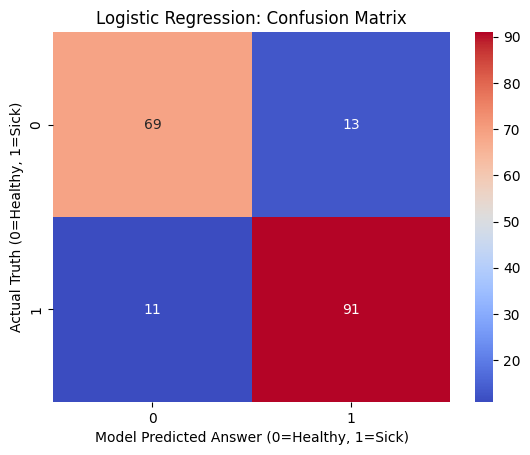

In [63]:
from sklearn.metrics import confusion_matrix

confion_matrix_log_reg = confusion_matrix(y_test,y_pred_log_reg)
display(confion_matrix_log_reg)

sns.heatmap(confion_matrix_log_reg , annot=True , cmap = 'coolwarm' )
plt.title('Logistic Regression: Confusion Matrix')
plt.xlabel('Model Predicted Answer (0=Healthy, 1=Sick)')
plt.ylabel('Actual Truth (0=Healthy, 1=Sick)')
plt.show()

##
## 4.2.2 Precision Score :  Recall Score : F1 Score : Accuracy Score
##

##### Accuracy Score : 
- Total Correctness = (TN+TP)/Total Patients = (TN+TP) / (TN + TP + FP + FN )
#### Recall(Sensitivity) : 
- Out of all people who actually had HeartDisease , how much of them model was able to recognize.
- ( TP ) / (TP + FN )
#### Precision : 
- Out of everyone who Model claimed were sick , how much of them were actually sick
- ( TP ) / ( TP + FP )
#### F1 Score : 
- Harmonic Average of Precision and Recall . To notice if one of them is poor and one is accurate
- 2 * (Precision*Recall)/(Precision+Recall)   . (H.M of a and b = (2) / (1/a + 1/b) ) 

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_score_log_reg = accuracy_score(y_test , y_pred_log)
recall_score_log_reg = recall_score(y_test, y_pred_log)
precision_score_log_reg = precision_score(y_test, y_pred_log)
f1_score_log_reg = f1_score(y_test, y_pred_log)

print(f"Accuracy:  {accuracy_score_log_reg:.4f} (Overall correctness)")
print(f"Recall:    {recall_score_log_reg:.4f} (How many sick patients we caught)")
print(f"Precision: {precision_score_log_reg:.4f} (How much we can trust a 'Sick' alarm)")
print(f"F1-Score:  {f1_score_log_reg:.4f} (The balanced compromise)")

Accuracy:  0.8696 (Overall correctness)
Recall:    0.8922 (How many sick patients we caught)
Precision: 0.8750 (How much we can trust a 'Sick' alarm)
F1-Score:  0.8835 (The balanced compromise)


##
## 4.2.3 ROC-AUC Scores
##

#### ROC Curve : 
- ROC stands for Reciever Operating Characteristic
- It plots True Positive Rate(Y axis) and False Positive Rate(X axis) on various thresholds of flagging them as sick / healthy like 0.5,0.9 etc.
- Left Most point of graph is 99% threshold and going right we go towards lesser let's say 10% threshold
- 90% here means If Model is  99% sure that Patient is sick , then it will flag them as sick and 10% sure means even if my 10 percent sure patient is sick we will flag them as sick and run more tests on them to verify then taking risk of clarifying them healthy
- In healthcare , generally threshold is 0.3-0.4 because , here if one actual sick patient is missed it can lead to death .
- But in times like pandemic or something , where number of beds are in less supply for patients we increase this threshold to 50 or 60% to make sure patients with higher chances of being sick are checked first thus decreasing false positive rate ...
     - When Flagging Percentage (threshold) is high (0.6 or 0.9) -
          - Left Side of Graph
          -  False positive decreases to 0 as if a person is detected with this much high percentage , it has to be sick
          -  True Positive decreases to  0 as there are rare chances model describes someone with this much high accuracy as its ideal , not practical
    - When Flaggin Percentage (threshold) is less(0.1 or 0.2)
         - Right Side of graph
         - False Positive rate increases to 1 as we want any actual sick to be not detected so we detect at this low percentage not leaving any chances
         - True Positive rate increases to 1 as such a low percentage of threshold will have every sick patient in it so False alarm of being sick by model but not actually sick increases

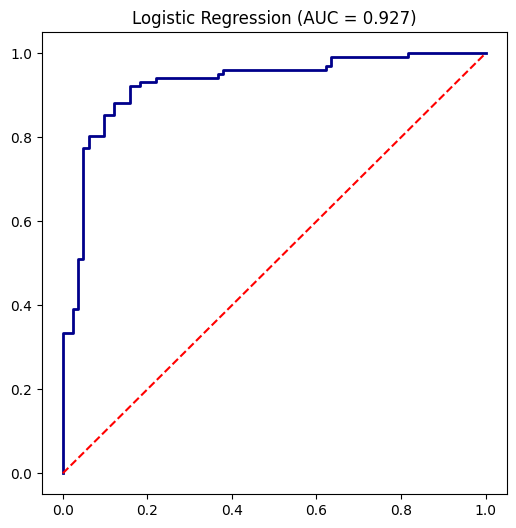

In [92]:
from sklearn.metrics import roc_curve , roc_auc_score

# roc_curve gives three lists as [false positive rates] [true positive rates] [Thresholds] 
false_positive_rate  , true_positive_rate , thresholds = roc_curve(y_test,y_prob_log_reg)

# Auc is area under the curve 
auc_score = roc_auc_score(y_test,y_prob_log_reg)

plt.figure(figsize=(6, 6))

# roc curve
plt.plot(false_positive_rate, true_positive_rate, color='darkblue', linewidth=2)
plt.title(f"Logistic Regression (AUC = {auc_score:.3f})")
# If the decision was completely random we would have got a straight line 
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing (AUC = 0.500)')

#### AUC : Area under Curve
- If Model is completelty broken and just similar to flipping a coin for healthy and sick patient classification , the trade-off is 1 to 1
To alarm 50% of sick people it alarms 50% of healthy people as well , which is diagonal straight line with area 0.5
- auc score of 0.5 or lesser is simply worse than classifying patients by flipping a coin
- Industry Standard is auc>0.85 is perfect for categorical classification


#
## 4.3 - KNN  Model
#

### K - Nearest Neighbours : 
- KNN does absolutely zero learning during .fit() phase , it doesnt memorize average , variance or any calculation of feature weights in .fit() phase
- KNN just memorizes X_train during fitting . It just plots data points in space during .fit()
- KNN works in dimensions usually = Number of features in dataset . When a new patient arrives it calcualtes Euclidean distance from every data point .
- As we are calculating distance , if new patient's BP was 140 distance away and age qas 20 distance away , it would consider BP 7x times further just because the number is bigger
- Thus , we need Feature Scaling in KNN models due to calculation of distances
- In classification , majority vote is counted and Regression , mean of nearest K neighbours is taken

### How to Choose K value (Hyper Parameter Tuning)  :
- If K=1 : Extreme Overfitting , model looks at the single closest patient .
    - But what if that patient was an extreme outlier , if that is the case model is just memorizing the noise(not finding actual pattern)
- If K=N (918) : Extreme Underfitting , model looks at every patient in hospital and takes a majority vote without accounting for any feature patterns like blood pressure , heart rate etc..
- Generally , we start with K = SqaureRoot(N)

### Finding Best K : (Hyper-Parameter) Value

In [139]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

k_values_to_test = np.arange(1,50,2)
display(k_values_to_test)

f1_scores_list = []

for k in k_values_to_test :
    
    knn_temp_model = KNeighborsClassifier(n_neighbors=k)
    knn_temp_model.fit(X_train,y_train)

    y_pred_temp_knn_model = knn_temp_model.predict(X_test)
    f1score = f1_score( y_test , y_pred_temp_knn_model)

    f1_scores_list.append(f1score)

max_f1_score_index = np.argmax(f1_scores_list)

optimal_K_value = k_values_to_test[max_f1_score_index]
max_f1_score = f1_scores_list[ max_f1_score_index ]

print("\n\n\nMost Optimal K value : ",optimal_K_value)
print("\nMaximum F1 Score     : ",max_f1_score )

array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33,
       35, 37, 39, 41, 43, 45, 47, 49])




Most Optimal K value :  11

Maximum F1 Score     :  0.8878048780487805


In [134]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=11) # root of 918(N) is nearly 29
knn_model.fit(X_train, y_train) 

y_prediction_knn  = knn_model.predict(X_test)

# Is is a 2d matrix with column 0 as healthy percentage and column 1 as sick
y_probability_knn = knn_model.predict_proba(X_test)[:,1]


#
## KNN -  Evaluation Metrics :
#


## 4.3.1 - Accuracy Score : Precision Score :  Recall Score : F1 Score : AUC Score

In [141]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score,roc_curve

accuracy_score_knn    = accuracy_score(y_test,y_prediction_knn)
recall_score_knn      = recall_score(y_test,y_prediction_knn)
precision_score_knn   = precision_score(y_test,y_prediction_knn)
f1_score_knn          = f1_score(y_test,y_prediction_knn)
auc_score_knn         =  roc_auc_score(y_test, y_probability_knn)

print("K-NEAREST NEIGHBORS (Optimal K : 11) REPORT ")
print(f"Accuracy:  {accuracy_score_knn:.4f}")
print(f"Recall:    {recall_score_knn:.4f}")
print(f"Precision: {precision_score_knn:.4f}")
print(f"F1-Score:  {f1_score_knn:.4f}")
print(f"ROC-AUC:   {auc_score_knn:.4f} ")


K-NEAREST NEIGHBORS (Optimal K : 11) REPORT 
Accuracy:  0.8750
Recall:    0.8922
Precision: 0.8835
F1-Score:  0.8878
ROC-AUC:   0.9241 


## 4.3.2 Confusion Matrix 

Text(120.72222222222221, 0.5, 'Actual Truth (0=Healthy, 1=Sick)')

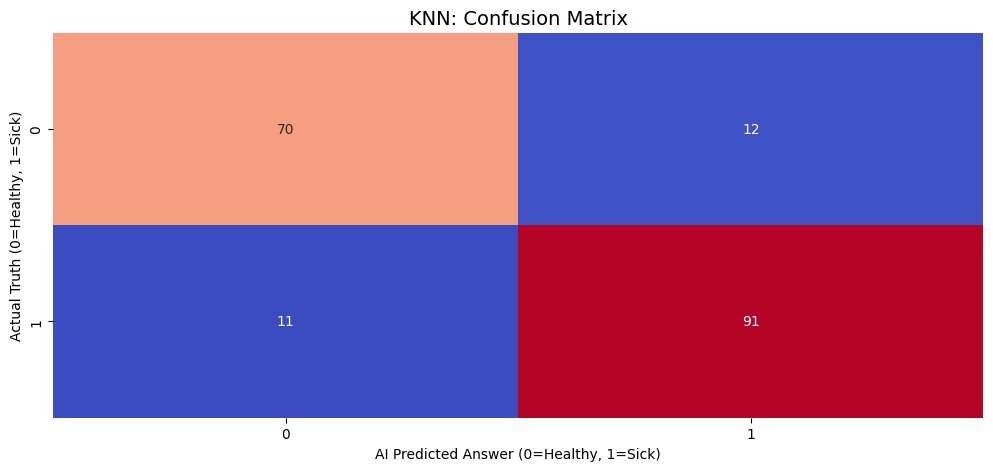

In [142]:
plt.figure(figsize=(12, 5)) 

confusion_matrix_knn = confusion_matrix(y_test, y_prediction_knn)
sns.heatmap(confusion_matrix_knn, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.title('KNN: Confusion Matrix', fontsize=14)
plt.xlabel('AI Predicted Answer (0=Healthy, 1=Sick)')
plt.ylabel('Actual Truth (0=Healthy, 1=Sick)')

## 4.3.3 ROC - AUC Curve 

### ROC Curve In KNN :
- KNN decides on majority , for eg K=25 and for a new patient 18 nearest neighbors had HeartDisease
- It calcualtes probabilty (majority) . Here 18/25 =0.72 > 0.50 :--> Thus by majority with 72% confidence , patient will be having a HeartDisease
- Roc Curve will need the probabilities for every patient according to their K nearest Neighbors
- y_probability_knn has the probability for every patient in X_test

### Staircase Effect : 
- If K=25 , my probabilities can only be 1/25 , 2/25..25/25
- Thus model can guess only 4% , 8% , 12% ..... 100 % sure that patient is sick
- It is mathematically impossible for model to say 73% or 63% sure as it uses simple voting strategy which gives fractions
- Thus ROC curve of KNN graph is like a staircase with 26 steps jagged

In [ ]:
from sklearn.metrics import roc_curve , auc_score

false_positive_rate , true_positive_rate , thresholds_knn = roc_curve